In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("vivmankar/asian-vs-african-elephant-image-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 51.8M/51.8M [00:00<00:00, 98.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1):
['dataset']


In [ ]:
import os

# Update path to match the 'dataset' directory in the elephant dataset
data_path = os.path.join(path, 'dataset')

# List subdirectories (usually 'train' and 'test' classes)
if os.path.exists(data_path):
    print(f"Classes in dataset: {os.listdir(data_path)}")
else:
    print(f"Directory not found: {data_path}")

Classes in dataset: ['test', 'train']



--- Sample Images from Dataset (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1/dataset) ---
Found 1028 images. Displaying 6 sample images:


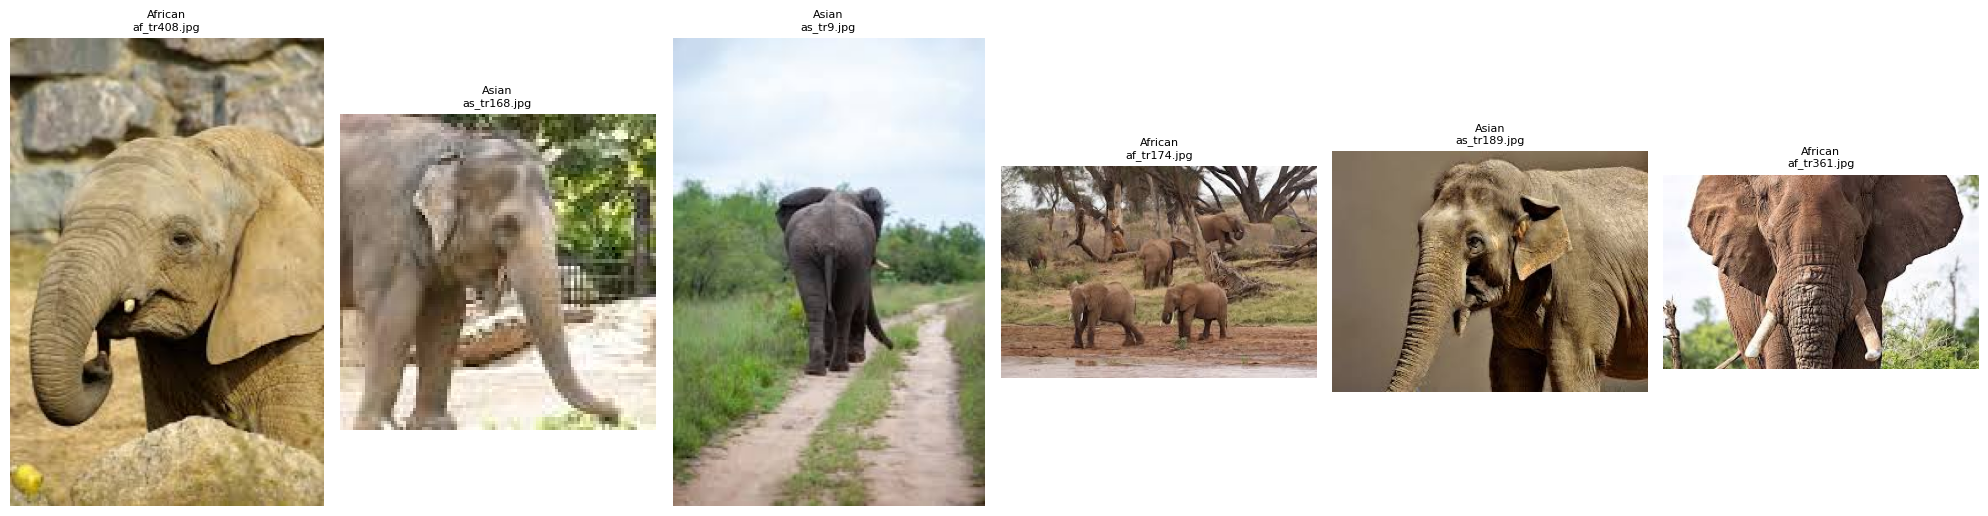

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent folder) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct 'dataset' path
data_path = os.path.join(path, 'dataset')
print(f"\n--- Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import time

# 1. Check GPU Availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cpu


In [ ]:
# 2. Prepare DataLoaders and Build DenseNet
train_dir = os.path.join(data_path, 'train')
test_dir = os.path.join(data_path, 'test')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize DenseNet121
model = models.densenet121(weights='IMAGENET1K_V1')
# Freeze features
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Training Loop
epochs = 10
history = {'train_loss': [], 'test_acc': []}

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    history['train_loss'].append(epoch_loss)

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    history['test_acc'].append(accuracy)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Test Acc: {accuracy:.2f}%")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 246MB/s]


Starting Training...
Epoch 1/10 - Loss: 0.6702 - Test Acc: 84.57%
Epoch 2/10 - Loss: 0.5727 - Test Acc: 91.49%
Epoch 3/10 - Loss: 0.5464 - Test Acc: 92.02%
Epoch 4/10 - Loss: 0.5574 - Test Acc: 90.96%
Epoch 5/10 - Loss: 0.4912 - Test Acc: 93.09%
Epoch 6/10 - Loss: 0.5067 - Test Acc: 90.96%
Epoch 7/10 - Loss: 0.4709 - Test Acc: 94.68%
Epoch 8/10 - Loss: 0.4684 - Test Acc: 90.43%
Epoch 9/10 - Loss: 0.4723 - Test Acc: 93.09%
Epoch 10/10 - Loss: 0.4441 - Test Acc: 92.02%


In [ ]:
# 3. Summarize Results
final_accuracy = history['test_acc'][-1]
print(f"--- Training Summary ---")
print(f"Total Epochs: {epochs}")
print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Test Accuracy: {final_accuracy:.2f}%")
print(f"Classes trained: {train_dataset.classes}")

--- Training Summary ---
Total Epochs: 10
Final Training Loss: 0.4441
Final Test Accuracy: 92.02%
Classes trained: ['African', 'Asian']


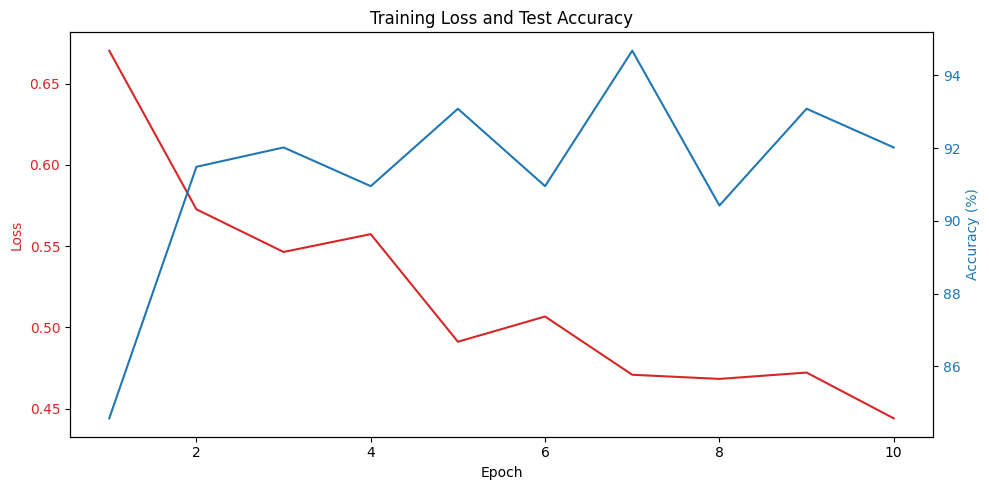

In [ ]:
# 4. Display Training Charts
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(range(1, epochs + 1), history['train_loss'], color='tab:red', label='Train Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy (%)', color='tab:blue')
ax2.plot(range(1, epochs + 1), history['test_acc'], color='tab:blue', label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Training Loss and Test Accuracy')
fig.tight_layout()
plt.show()